# ML Models Interpretability

Centralized interpretability for every classical ML notebook in `notebooks/ml-models`:

- Ridge (`model_ridge.ipynb`)
- Random Forest (`model_random_forest.ipynb`)
- SVM (`model_svm.ipynb`)
- XGBoost (`model_xgboost.ipynb`)
- Weighted Ensemble (`model_weighted_ensemble.ipynb`)

All generated plots and tables live in this folder under `outcome/`.


## Policy

The notebook keeps the source notebook for each model explicit. For the single-model explanations, it uses the same model family and hyperparameters defined in those notebooks, but fits local interpretability copies on the weighted-ensemble feature-selected top descriptors. That keeps all SHAP plots comparable and runnable.

If a local interpretability copy already exists in `outcome/models`, it is loaded instead of refitted. The weighted ensemble itself is imported from its saved notebook artifact and explained as a weighted sum of its active components.


In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'interpratability':
    NOTEBOOK_DIR = Path('notebooks/ml-models/interpratability').resolve()

ML_MODELS_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = ML_MODELS_DIR.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.modeling import load_feature_selected_arrays

OUTCOME_DIR = NOTEBOOK_DIR / 'outcome'
FIGURES_DIR = OUTCOME_DIR / 'figures'
TABLES_DIR = OUTCOME_DIR / 'tables'
INTERP_MODEL_DIR = OUTCOME_DIR / 'models'
for directory in (FIGURES_DIR, TABLES_DIR, INTERP_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FEATURE_BUDGET = 100
BACKGROUND_SIZE = 40
EXPLAIN_SIZE = 160
SVM_EXPLAIN_SIZE = 8
MAX_DISPLAY = 20

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'axes.grid': True, 'grid.alpha': 0.25})


## Source Notebooks And Data

The feature space is the ranked feature-selection table already used by the weighted ensemble. This avoids explaining thousands of mostly sparse descriptors and makes the beeswarm plots readable.


In [2]:
MODEL_NOTEBOOKS = {
    'ridge': ML_MODELS_DIR / 'model_ridge.ipynb',
    'random_forest': ML_MODELS_DIR / 'model_random_forest.ipynb',
    'svm': ML_MODELS_DIR / 'model_svm.ipynb',
    'xgboost': ML_MODELS_DIR / 'model_xgboost.ipynb',
    'weighted_ensemble': ML_MODELS_DIR / 'model_weighted_ensemble.ipynb',
}

(
    X_train_all,
    X_valid_all,
    X_test_all,
    y_train,
    y_valid,
    y_test,
    feature_names_all,
    preprocessor,
) = load_feature_selected_arrays()

feature_budget = min(FEATURE_BUDGET, X_train_all.shape[1])
X_train = X_train_all[:, :feature_budget].astype(np.float32)
X_valid = X_valid_all[:, :feature_budget].astype(np.float32)
X_test = X_test_all[:, :feature_budget].astype(np.float32)
feature_names = np.asarray([str(name) for name in feature_names_all[:feature_budget]])
clean_feature_names = np.asarray([name.replace('num__', '').replace('cat__', '') for name in feature_names])

source_table = pd.DataFrame([
    {
        'model': name,
        'source_notebook': str(path.relative_to(PROJECT_ROOT)),
        'interpretability_feature_budget': feature_budget,
    }
    for name, path in MODEL_NOTEBOOKS.items()
])
source_table.to_csv(TABLES_DIR / 'model_sources.csv', index=False)
source_table


,model,source_notebook,interpretability_feature_budget
0,ridge,notebooks/ml-models/model_ridge.ipynb,100
1,random_forest,notebooks/ml-models/model_random_forest.ipynb,100
2,svm,notebooks/ml-models/model_svm.ipynb,100
3,xgboost,notebooks/ml-models/model_xgboost.ipynb,100
4,weighted_ensemble,notebooks/ml-models/model_weighted_ensemble.ipynb,100


## Import / Fit Interpretability Models

These local models mirror the model definitions from the source notebooks and are saved in `interpratability/outcome/models` so repeated runs do not retrain them.


In [3]:
def regression_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def local_model_path(name):
    return INTERP_MODEL_DIR / f'{name}_interpretability_model.pkl'


def load_or_fit(name, factory, fit_fn=None):
    path = local_model_path(name)
    if path.exists():
        return joblib.load(path), 'local_interpretability_artifact'
    model = factory()
    if fit_fn is None:
        model.fit(X_train, y_train)
    else:
        fit_fn(model)
    joblib.dump(model, path)
    return model, 'fit_from_source_notebook_config'


def fit_xgboost(model):
    try:
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    except Exception as exc:
        warnings.warn(f'XGBoost CUDA failed; retrying on CPU. Details: {exc}')
        model.set_params(device='cpu')
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)


MODEL_FACTORIES = {
    'ridge': lambda: RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=None),
    'random_forest': lambda: RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'svm': lambda: SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    'xgboost': lambda: xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        random_state=RANDOM_STATE,
    ),
}

models = {}
model_rows = []
for name, factory in MODEL_FACTORIES.items():
    print(f'Loading/fitting {name}...')
    fit_fn = fit_xgboost if name == 'xgboost' else None
    model, source = load_or_fit(name, factory, fit_fn=fit_fn)
    models[name] = model
    model_rows.append({
        'model': name,
        'source': source,
        'source_notebook': str(MODEL_NOTEBOOKS[name].relative_to(PROJECT_ROOT)),
        'local_artifact': str(local_model_path(name).relative_to(PROJECT_ROOT)),
    })

model_imports = pd.DataFrame(model_rows)
model_imports.to_csv(TABLES_DIR / 'model_imports.csv', index=False)
model_imports


Loading/fitting ridge...
Loading/fitting random_forest...
Loading/fitting svm...
Loading/fitting xgboost...


,model,source,source_notebook,local_artifact
0,ridge,local_interpretability_artifact,notebooks/ml-models/model_ridge.ipynb,notebooks/ml-models/interpratability/outcome/m...
1,random_forest,local_interpretability_artifact,notebooks/ml-models/model_random_forest.ipynb,notebooks/ml-models/interpratability/outcome/m...
2,svm,local_interpretability_artifact,notebooks/ml-models/model_svm.ipynb,notebooks/ml-models/interpratability/outcome/m...
3,xgboost,local_interpretability_artifact,notebooks/ml-models/model_xgboost.ipynb,notebooks/ml-models/interpratability/outcome/m...


## Weighted Ensemble Import

The weighted ensemble is imported from `model_weighted_ensemble.ipynb` output. It already contains fitted component models, optimized weights, and the selected feature names.


In [4]:
weighted_ensemble_path = ML_MODELS_DIR / 'outcome' / 'models' / 'weighted_ensemble_model.joblib'
if not weighted_ensemble_path.exists():
    raise FileNotFoundError(f'Missing weighted ensemble artifact: {weighted_ensemble_path}')
weighted_ensemble = joblib.load(weighted_ensemble_path)

ensemble_weights = pd.DataFrame([
    {'component': name, 'weight': float(weight)}
    for name, weight in weighted_ensemble['weights'].items()
]).sort_values('weight', ascending=False)
ensemble_weights.to_csv(TABLES_DIR / 'weighted_ensemble_weights.csv', index=False)
ensemble_weights


,component,weight
5,xgboost,8.664925e-01
2,random_forest,7.853505e-02
4,hist_gradient_boosting,5.497245e-02
3,extra_trees,8.134920e-17
0,ridge,2.393653e-19
1,elastic_net,1.667617e-19


## Prediction Check

Metrics are computed on the held-out test rows for the same feature-selected matrix used by the explanations.


In [5]:
def weighted_ensemble_predict(bundle, X):
    pred = np.zeros(X.shape[0], dtype=float)
    for name, weight in bundle['weights'].items():
        if abs(float(weight)) <= 1e-12:
            continue
        pred += float(weight) * np.asarray(bundle['models'][name].predict(X)).ravel()
    return pred

predictions = {name: np.asarray(model.predict(X_test)).ravel() for name, model in models.items()}
predictions['weighted_ensemble'] = weighted_ensemble_predict(weighted_ensemble, X_test)

prediction_metrics = pd.DataFrame([
    {'model': name, **regression_metrics(y_test, preds)}
    for name, preds in predictions.items()
]).sort_values('rmse')
prediction_metrics.to_csv(TABLES_DIR / 'prediction_metrics.csv', index=False)
prediction_metrics


,model,rmse,mae,r2
4,weighted_ensemble,0.562044,0.412033,0.646417
3,xgboost,0.566597,0.415941,0.640665
1,random_forest,0.587119,0.432500,0.614165
2,svm,0.599775,0.438368,0.597351
0,ridge,0.726891,0.544608,0.408589


## SHAP Helpers

Every model writes:

- `*_shap_beeswarm.png`
- `*_shap_waterfall.png`
- `*_shap_summary.csv`
- `*_waterfall_values.csv`


In [6]:
def sample_indices(n_rows, size, offset):
    rng = np.random.default_rng(RANDOM_STATE + offset)
    return rng.choice(n_rows, size=min(size, n_rows), replace=False)


def save_shap_outputs(model_name, explanation, X_explain_df, y_explain, pred_explain):
    values = np.asarray(explanation.values, dtype=float)
    if values.ndim == 3:
        values = values[:, :, 0]

    summary = pd.DataFrame({
        'model': model_name,
        'feature': list(explanation.feature_names),
        'mean_abs_shap': np.abs(values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False)
    summary.to_csv(TABLES_DIR / f'{model_name}_shap_summary.csv', index=False)

    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(explanation, max_display=MAX_DISPLAY, show=False)
    plt.title(f'{model_name}: SHAP beeswarm')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{model_name}_shap_beeswarm.png', bbox_inches='tight')
    plt.show()

    local_pos = int(np.argmax(np.abs(pred_explain - y_explain)))
    local_error = float(pred_explain[local_pos] - y_explain[local_pos])
    plt.figure(figsize=(10, 7))
    shap.plots.waterfall(explanation[local_pos], max_display=MAX_DISPLAY, show=False)
    plt.title(
        f'{model_name}: SHAP waterfall | '
        f'pred={pred_explain[local_pos]:.3f}, real={y_explain[local_pos]:.3f}, error={local_error:.3f}'
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{model_name}_shap_waterfall.png', bbox_inches='tight')
    plt.show()

    local_table = pd.DataFrame({
        'model': model_name,
        'feature': list(explanation.feature_names),
        'feature_value': X_explain_df.iloc[local_pos].to_numpy(),
        'shap_value': values[local_pos],
        'abs_shap_value': np.abs(values[local_pos]),
    }).sort_values('abs_shap_value', ascending=False)
    local_table.to_csv(TABLES_DIR / f'{model_name}_waterfall_values.csv', index=False)
    return summary


def explain_linear(model_name, model, explain_idx):
    background_idx = sample_indices(X_train.shape[0], BACKGROUND_SIZE, 10)
    background = pd.DataFrame(X_train[background_idx], columns=clean_feature_names)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.LinearExplainer(model, background)
    explanation = explainer(X_explain_df)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def explain_tree(model_name, model, explain_idx):
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.TreeExplainer(model, feature_names=list(clean_feature_names))
    values = np.asarray(explainer.shap_values(X_explain_df), dtype=float)
    if values.ndim == 3:
        values = values[:, :, 0]
    expected = explainer.expected_value
    if np.ndim(expected) == 0:
        base_values = np.full(X_explain_df.shape[0], float(expected))
    else:
        expected_arr = np.asarray(expected, dtype=float).reshape(-1)
        base_values = np.full(X_explain_df.shape[0], float(expected_arr[0])) if expected_arr.size == 1 else expected_arr
    explanation = shap.Explanation(values=values, base_values=base_values, data=X_explain_df.to_numpy(), feature_names=list(clean_feature_names))
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def explain_permutation(model_name, model, explain_idx):
    background_idx = sample_indices(X_train.shape[0], BACKGROUND_SIZE, 20)
    background = pd.DataFrame(X_train[background_idx], columns=clean_feature_names)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.Explainer(
        model.predict,
        shap.maskers.Independent(background),
        algorithm='permutation',
        feature_names=list(clean_feature_names),
    )
    explanation = explainer(X_explain_df, max_evals=2 * X_explain_df.shape[1] + 1, silent=True)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def xgboost_contrib_explanation(model, X_explain_df):
    booster = model.get_booster()
    dmatrix = xgb.DMatrix(X_explain_df.to_numpy(dtype=np.float32), feature_names=list(X_explain_df.columns))
    contribs = booster.predict(dmatrix, pred_contribs=True)
    contribs = np.asarray(contribs, dtype=float)
    values = contribs[:, :-1]
    base_values = contribs[:, -1]
    return shap.Explanation(
        values=values,
        base_values=base_values,
        data=X_explain_df.to_numpy(),
        feature_names=list(X_explain_df.columns),
    )


def explain_xgboost(model_name, model, explain_idx):
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explanation = xgboost_contrib_explanation(model, X_explain_df)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


## Ridge Interpretability

Source configuration: `model_ridge.ipynb`.

The SHAP global and local explanations provide a window into how the Ridge model perceives molecular structures in relation to the $LD_{50}$ (median lethal dose).

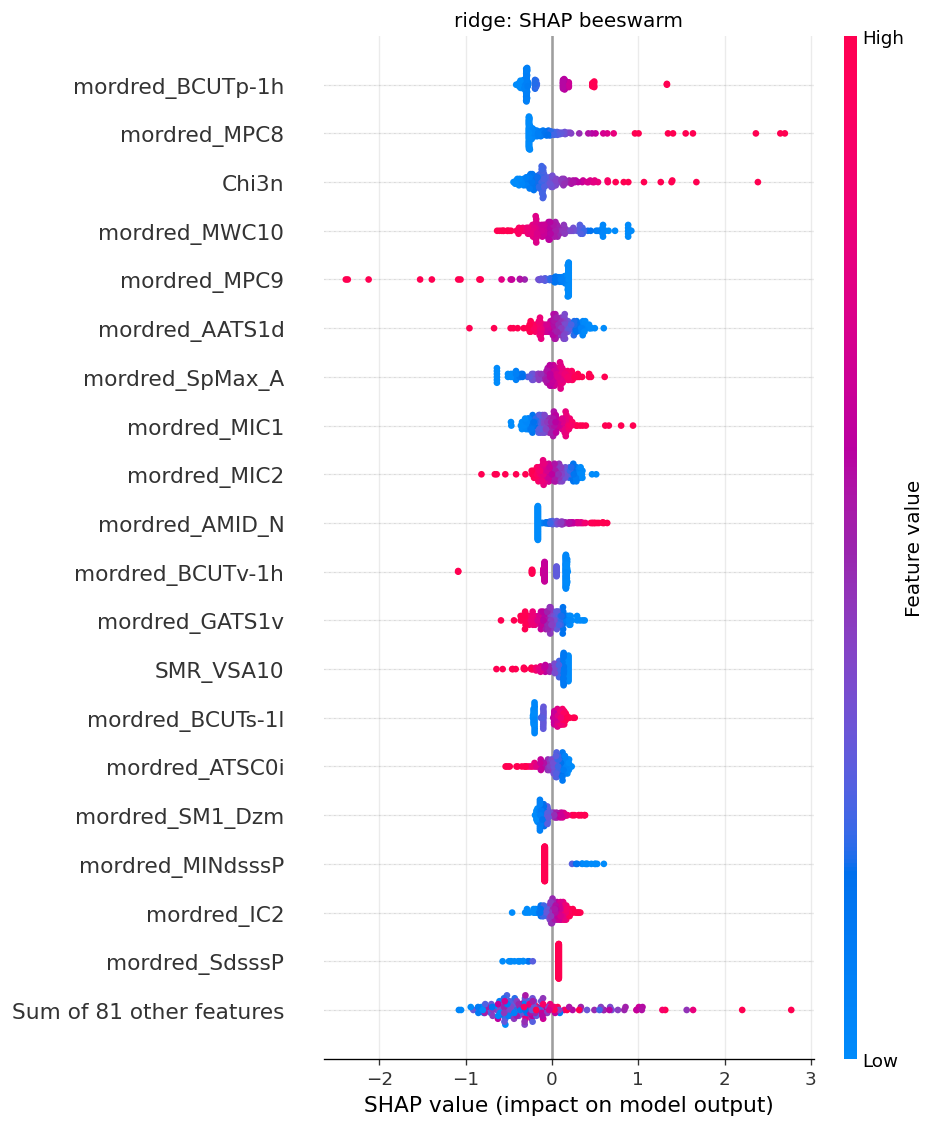

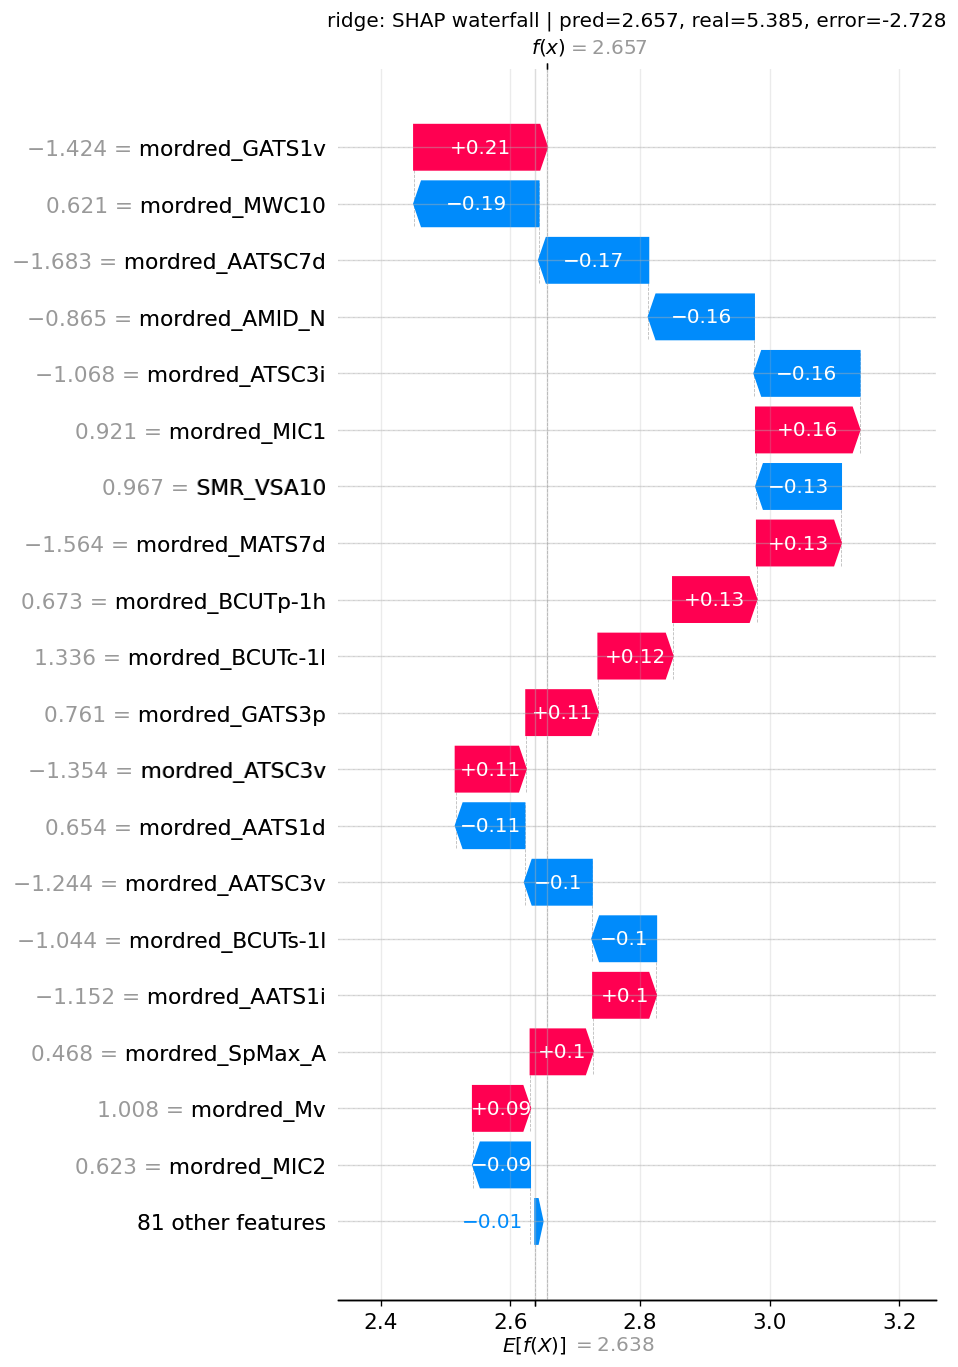

,model,feature,mean_abs_shap
4,ridge,mordred_BCUTp-1h,0.294430
22,ridge,mordred_MPC8,0.282375
62,ridge,Chi3n,0.255232
54,ridge,mordred_MWC10,0.242156
37,ridge,mordred_MPC9,0.229602
95,ridge,mordred_AATS1d,0.175037
64,ridge,mordred_SpMax_A,0.168546
0,ridge,mordred_MIC1,0.166850
6,ridge,mordred_MIC2,0.161308
57,ridge,mordred_AMID_N,0.159970


In [ ]:
explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 1)
ridge_summary = explain_linear('ridge', models['ridge'], explain_idx)
ridge_summary.head(MAX_DISPLAY)

### **Global Perspective: SHAP Beeswarm**
The beeswarm plot reveals the general trends of the most influential features across the entire dataset.

*   **mordred_BCUTp-1h (Polarizability)**: Higher values are strongly associated with higher SHAP values (lower toxicity). This suggests that more polarizable molecules in our dataset tend to be less toxic.
*   **mordred_MPC8 & mordred_MPC9 (Molecular Path Counts)**: These represent the number of paths of lengths 8 and 9 within the molecular graph. 
    *   For **MPC8**, higher values pull the prediction toward higher $LD_{50}$ (safer).
    *   Interestingly, for **MPC9**, the trend reverses: high values (pink dots) have a strong negative SHAP impact. This indicates that larger, more complex topological paths of length 9 are associated with increased toxicity in the model's logic.
*   **Chi3n (Connectivity Index)**: This descriptor captures molecular branching. Higher values correlate with higher $LD_{50}$ values, suggesting that specific branching patterns may decrease the acute toxicity of these small molecules.

### **Local Perspective: SHAP Waterfall**
The waterfall plot explains a specific prediction ($f(x) = 2.657$) by showing how individual features "push" the base value toward the final result.

*   **mordred_GATS1v (Geary Autocorrelation)**: In this specific case, a high value pushes the prediction up by **+0.21**, acting as a "protective" factor for this molecule.
*   **mordred_MWC10 (Molecular Walk Count)**: This feature pulls the prediction down by **-0.19**, indicating that long-range structural walks in this specific drug structure contribute to a lower (more toxic) $LD_{50}$.
*   **mordred_AATSC7d (Average Atom-type Centric Autocorrelation)**: This spatial distribution descriptor further decreases the predicted $LD_{50}$ by **-0.17**, highlighting how the specific arrangement of atoms at a topological distance of 7 influences the toxicity profile.

### **Conclusion on SHAP Validity**
> The results are chemically intuitive. The model prioritizes **polarizability** and **topological complexity** (Path and Walk counts), which are known to influence how a molecule interacts with biological membranes and enzymes. The inversion of impact between MPC8 and MPC9 suggests the model is capturing a specific structural threshold where increased size or complexity begins to correlate with adverse biological interactions.

## Random Forest Interpretability

Source configuration: `model_random_forest.ipynb`.

The SHAP analysis for the Random Forest model highlights how an ensemble of trees captures non-linear relationships to determine molecular toxicity. Compared to the linear Ridge model, Random Forest places more emphasis on specific information-theoretic and charge-based descriptors.

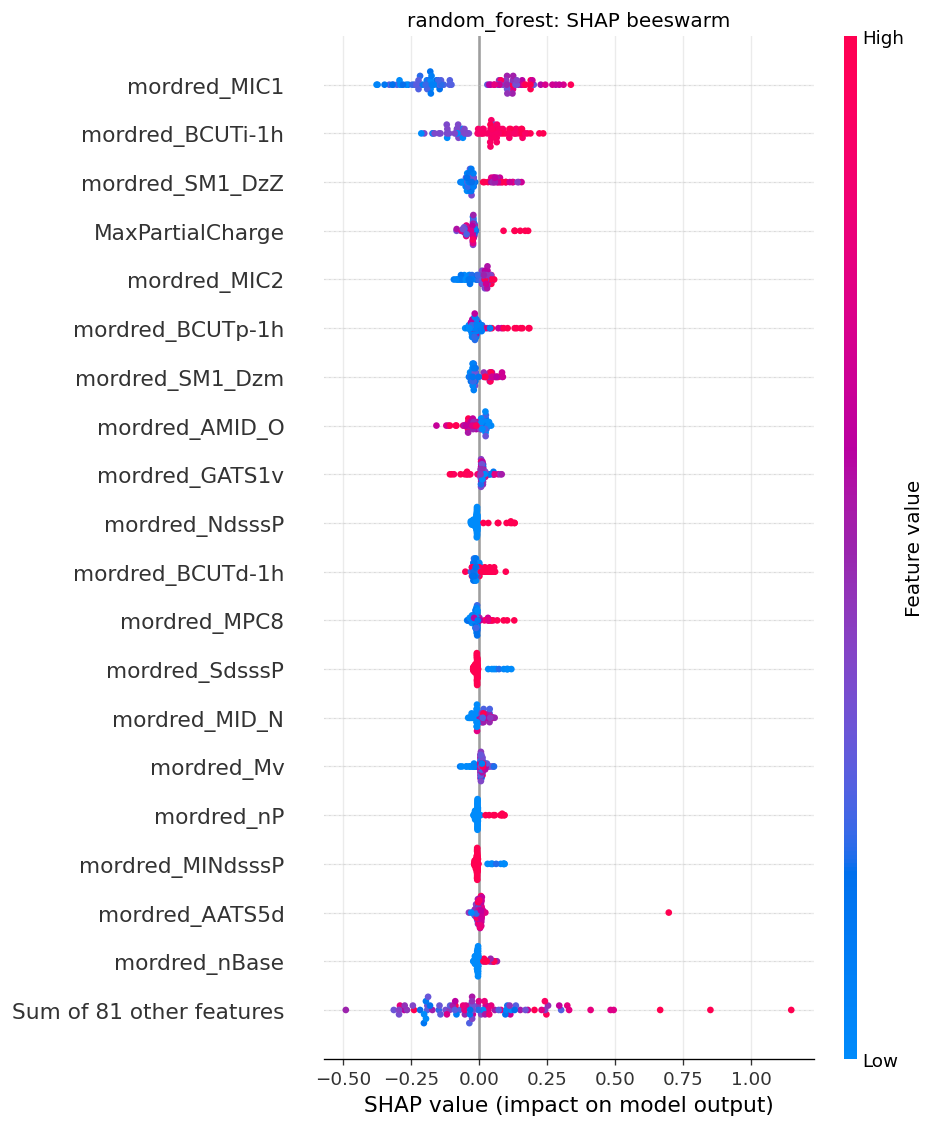

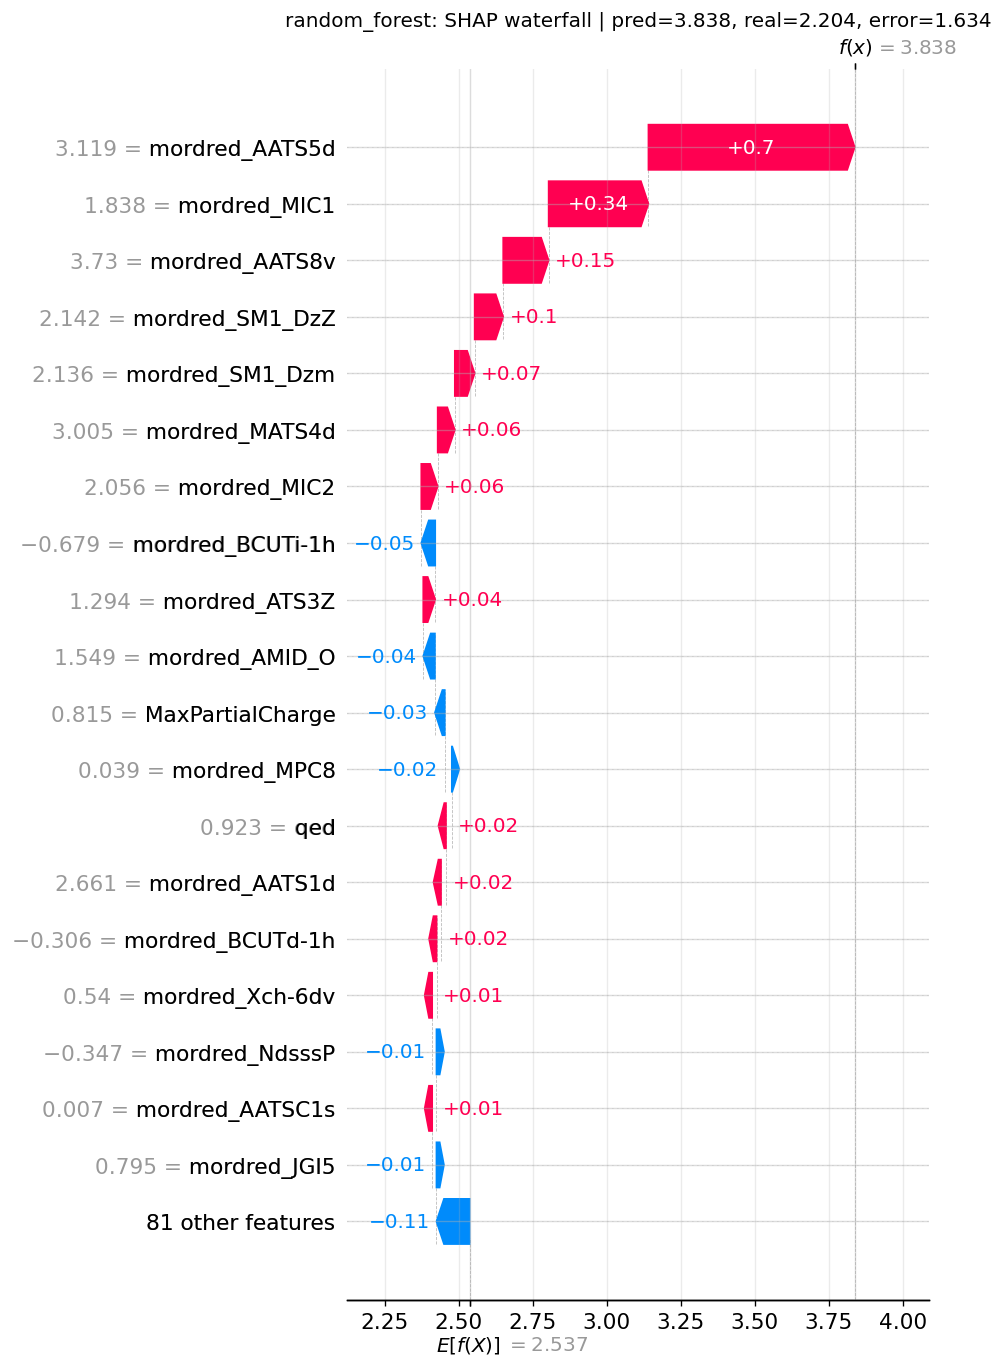

,model,feature,mean_abs_shap
0,random_forest,mordred_MIC1,0.181111
2,random_forest,mordred_BCUTi-1h,0.089971
3,random_forest,mordred_SM1_DzZ,0.049790
1,random_forest,MaxPartialCharge,0.039587
6,random_forest,mordred_MIC2,0.031205
4,random_forest,mordred_BCUTp-1h,0.030520
5,random_forest,mordred_SM1_Dzm,0.029458
19,random_forest,mordred_AMID_O,0.028566
16,random_forest,mordred_GATS1v,0.023042
8,random_forest,mordred_NdsssP,0.021412


In [8]:
explain_idx = sample_indices(X_test.shape[0], min(90, EXPLAIN_SIZE), 2)
random_forest_summary = explain_tree('random_forest', models['random_forest'], explain_idx)
random_forest_summary.head(MAX_DISPLAY)


### **Global Perspective: SHAP Beeswarm**
The beeswarm plot reveals the general trends of the most influential features across the entire dataset.
*   **mordred_MIC1**: ...   more high, higher shap val, sloweer slower shap val in a balanced way
*   **mordred_BCUTi_1h**: ... higher val, loweer shap
*   **mordred_BCUTp-1h (Polarizability)**: Higher values are strongly associated with higher SHAP values (lower toxicity). This suggests that more polarizable molecules in our dataset tend to be less toxic.
*   **mordred_MPC1 (Molecular Path Counts)**: These represent the number of paths of lengths 8 and 9 within the molecular graph.  higher values pull the prediction toward higher $LD_{50}$ (safer).


### **Local Perspective: SHAP Waterfall**
The waterfall plot explains a specific prediction ($f(x) = 2.657$) by showing how individual features "push" the base value toward the final result.

*   **mordred_AATSC5d (Average Atom-type Centric Autocorrelation)**: ...

### **Conclusion on SHAP Validity**
> The results are chemically intuitive...

### **Global Perspective: SHAP Beeswarm**
The beeswarm plot reveals the general trends of the most influential features across the entire dataset.

*   **mordred_MIC1 (Modified Information Content)**: This descriptor, which measures molecular complexity through atom neighborhoods, is the most influential. We observe a balanced, positive relationship: higher MIC1 values lead to higher SHAP values, consistently pulling the prediction toward a safer (less toxic) $LD_{50}$.
*   **mordred_BCUTi-1h (Ionization Potential)**: This descriptor relates to the electron-holding capacity of the molecule. Higher values clearly correspond to lower SHAP values, indicating that increased ionization potential is a driver for higher toxicity in this model.
*   **mordred_BCUTp-1h (Polarizability)**: Consistent with the Ridge results, higher polarizability values are associated with higher SHAP values. This reinforces the finding that more polarizable molecules tend to exhibit lower acute toxicity in this chemical space.
*   **MaxPartialCharge**: This represents the highest positive partial charge on an atom. Higher charges tend to have a positive impact on the SHAP value, suggesting that specific charge distributions are favored for reduced toxicity.

### **Local Perspective: SHAP Waterfall**
The waterfall plot explains a specific prediction ($f(x) = 2.657$) by showing how individual features "push or pull" the base value toward the final result.

*   **mordred_AATSC5d (Average Atom-type Centric Autocorrelation)**: In this specific prediction, a high value of this descriptor (3.119) provides a massive positive contribution of **+0.70**. This spatial distribution of atom types at a topological distance of 5 is the primary reason this specific molecule is predicted to be relatively safe.
*   **mordred_MIC1**: Adding to the local safety profile, the MIC1 value contributes another **+0.34**, consistent with the global trend.
*   **mordred_AATS8v (Average Atom-type Centric Autocorrelation - Van der Waals volume)**: This descriptor further increases the $LD_{50}$ by **+0.15**, showing how volume distribution at distance 8 impacts the local prediction.

### **Conclusion on SHAP Validity**
> The Random Forest results are highly stable. By prioritizing **Information Content (MIC1)** and **BCUT descriptors (ionization/polarizability)**, the model effectively captures both the structural complexity and the electronic nature of the drugs. The strong localized impact of **autocorrelation descriptors (AATSC)** in the waterfall plot suggests that the model is particularly sensitive to the spatial arrangement of chemical groups, which is a key factor in biological toxicity mechanisms.

## SVM Interpretability

Source configuration: `model_svm.ipynb`.

The SHAP analysis for the Support Vector Machine (SVM) model reveals a more specialized feature prioritization, likely due to the kernel's ability to map descriptors into a high-dimensional space where toxicity boundaries are defined.


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


...

/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


/home/luca/miniconda3/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


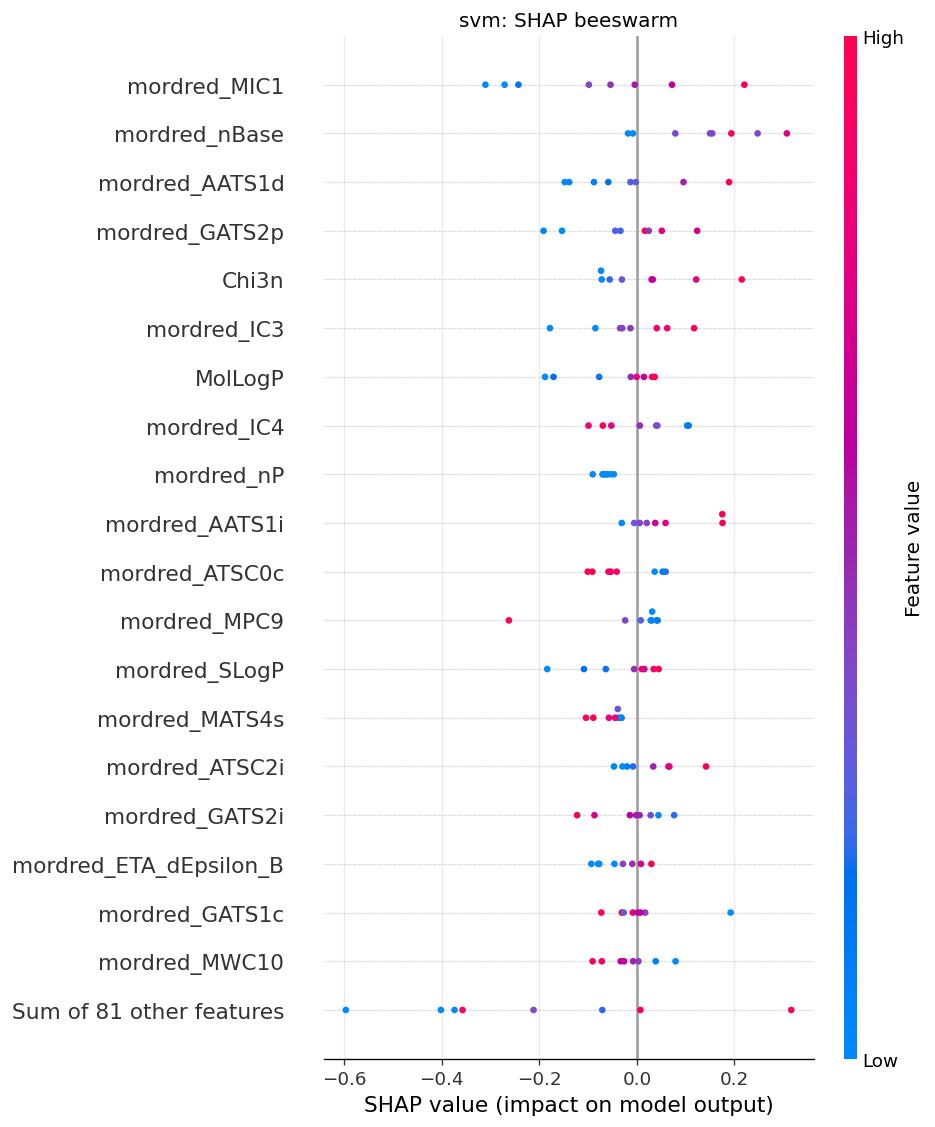

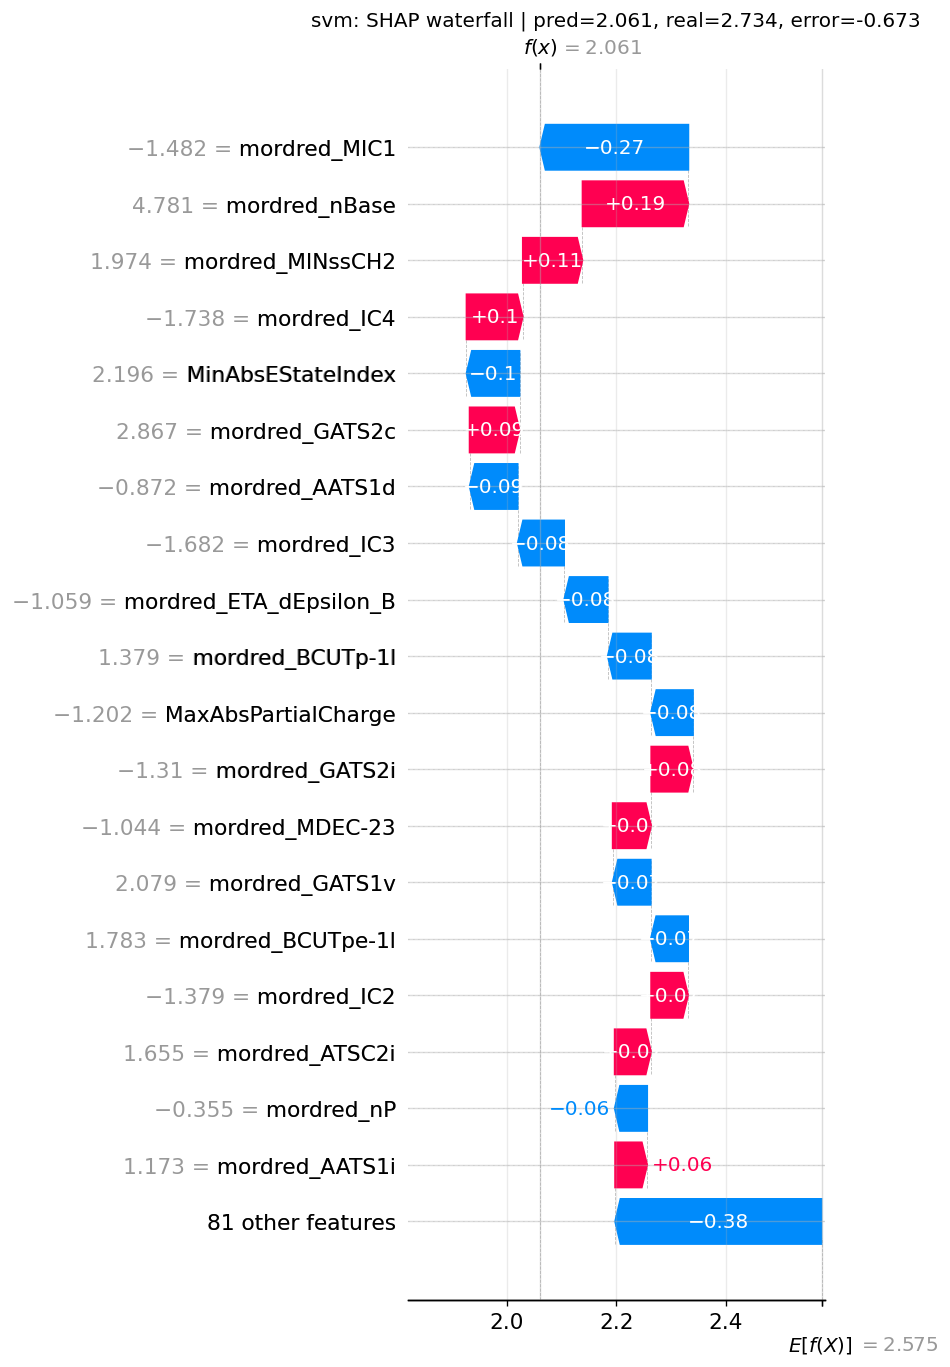

,model,feature,mean_abs_shap
0,svm,mordred_MIC1,0.159116
69,svm,mordred_nBase,0.144707
95,svm,mordred_AATS1d,0.091590
97,svm,mordred_GATS2p,0.079718
62,svm,Chi3n,0.078885
13,svm,mordred_IC3,0.070051
65,svm,MolLogP,0.066388
47,svm,mordred_IC4,0.064733
12,svm,mordred_nP,0.064523
55,svm,mordred_AATS1i,0.063696


In [9]:
explain_idx = sample_indices(X_test.shape[0], SVM_EXPLAIN_SIZE, 3)
svm_summary = explain_permutation('svm', models['svm'], explain_idx)
svm_summary.head(MAX_DISPLAY)


### **Global Perspective: SHAP Beeswarm**
In the beeswarm plot, the relationship between feature values and SHAP values appears more sparse, indicating that the SVM relies on specific structural "tipping points" rather than broad linear trends.

*   **mordred_MIC1 (Information Content)**: As seen in previous models, this descriptor remains a top predictor. High values correlate with positive SHAP values, suggesting that increased structural complexity generally signals a safer (lower toxicity) profile.
*   **mordred_nBase (Number of Basic Groups)**: This feature shows a clear trend where higher values lead to higher SHAP values. This implies that the presence of basic functional groups in the drug molecule is associated with decreased acute toxicity.
*   **mordred_AATS1d (Average Atom-type Centric Autocorrelation)**: Higher values of this spatial descriptor tend to pull the SHAP value upward, reinforcing the importance of atom-type distribution at short topological distances for predicting safety.
*   **Chi3n (Connectivity Index)**: Higher molecular branching (captured by Chi3n) correlates with higher $LD_{50}$ values. This suggests that specific branched frameworks are less likely to trigger acute toxic responses compared to linear chains.

### **Local Perspective: SHAP Waterfall**
The waterfall plot explains a specific prediction ($f(x) = 2.061$, which is more toxic than the average) by decomposing the impact of local features.

*   **mordred_MIC1**: In this specific molecule, a low value of MIC1 (-1.482) **pushes the prediction down by -0.27**, significantly increasing the predicted toxicity.
*   **mordred_nBase**: Conversely, a high number of basic groups (4.781) **pushes the prediction up by +0.19**, acting as the primary mitigating factor against toxicity for this instance.
*   **mordred_MINssCH2 (Atom-type Centric Autocorrelation)**: A high value here (1.974) further **pushes the prediction up by +0.11**, illustrating how specific methylene group arrangements can improve the safety score of a local prediction.

### **Conclusion on SHAP Validity**
> The SVM's focus on **basicity (nBase)** and **complexity (MIC1)** is chemically relevant, as the ionization state and structural intricacy are key determinants of a drug's pharmacokinetics and toxicological interaction. The sparsity of the beeswarm plot confirms that the SVM is effectively identifying non-linear decision boundaries, providing a distinct but complementary perspective to the ensemble and linear models.

## XGBoost Interpretability

Source configuration: `model_xgboost.ipynb`.

The SHAP analysis for the XGBoost model demonstrates how a gradient boosting framework utilizes decision trees to capture complex, non-linear interactions between molecular descriptors to estimate acute toxicity.

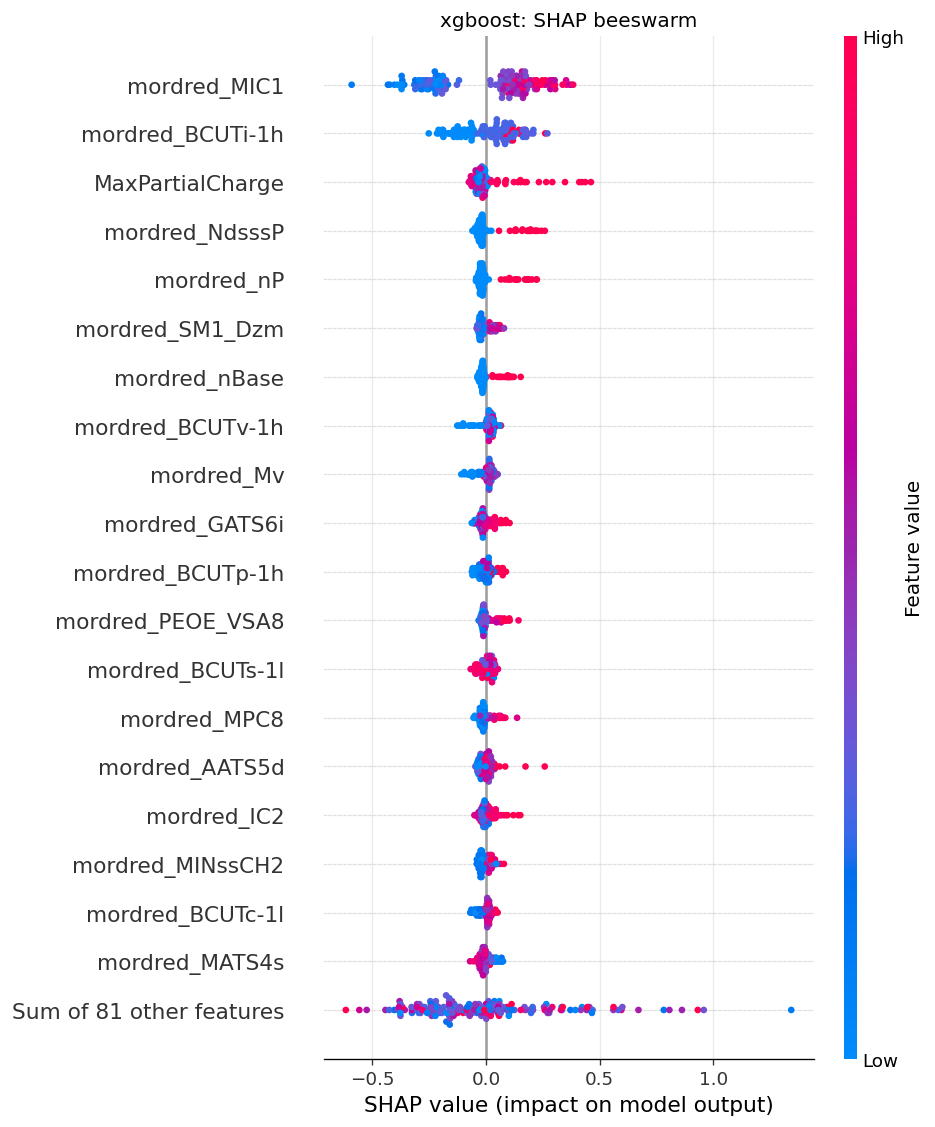

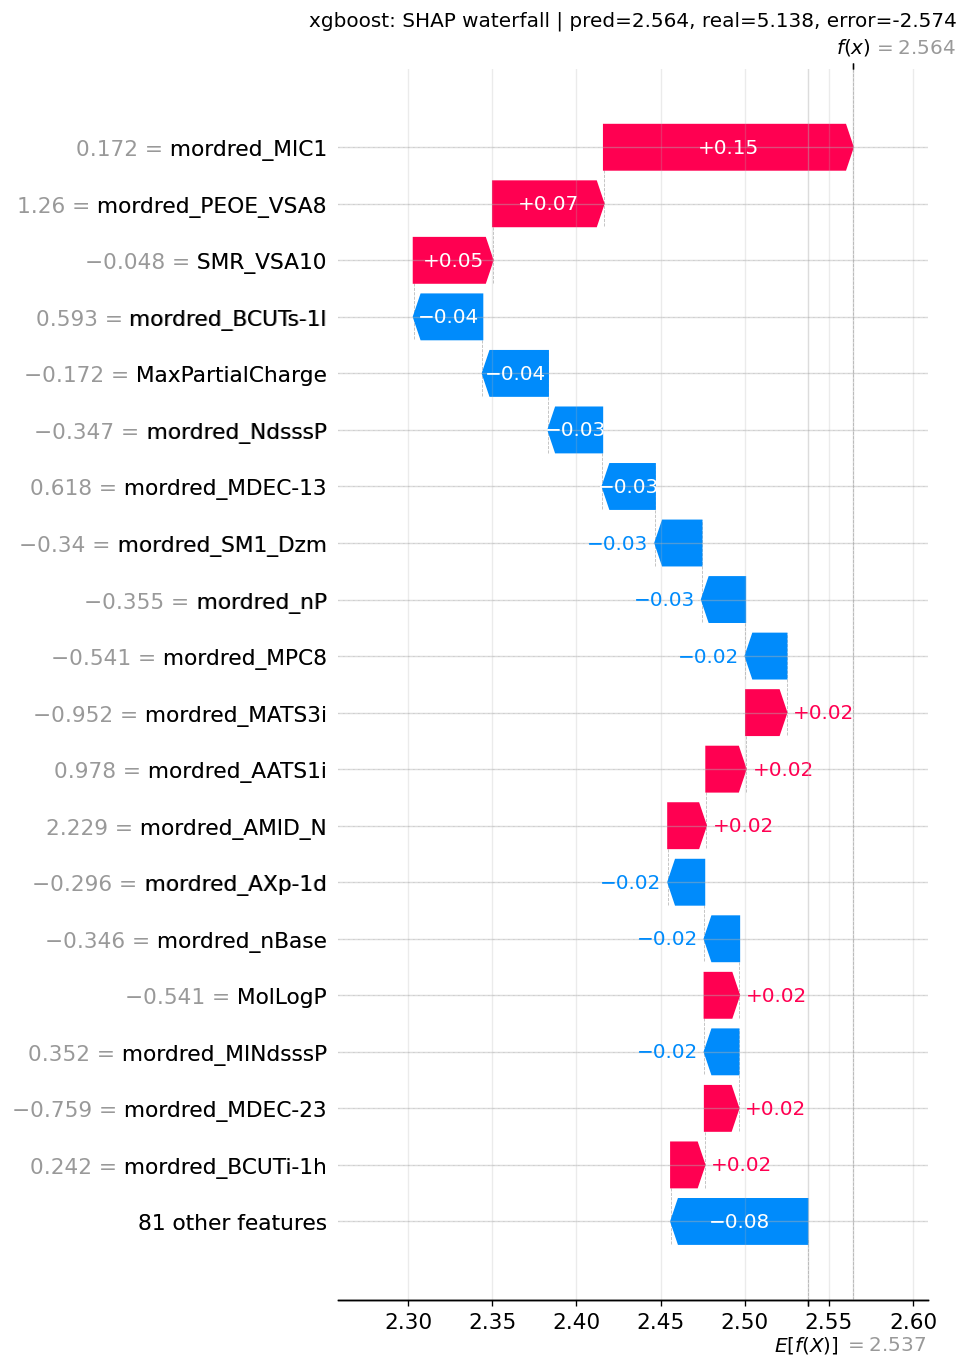

,model,feature,mean_abs_shap
0,xgboost,mordred_MIC1,0.204839
2,xgboost,mordred_BCUTi-1h,0.098225
1,xgboost,MaxPartialCharge,0.049612
8,xgboost,mordred_NdsssP,0.044595
12,xgboost,mordred_nP,0.036771
5,xgboost,mordred_SM1_Dzm,0.028202
69,xgboost,mordred_nBase,0.027027
75,xgboost,mordred_BCUTv-1h,0.025603
20,xgboost,mordred_Mv,0.023716
88,xgboost,mordred_GATS6i,0.022982


In [10]:
explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 4)
xgboost_summary = explain_xgboost('xgboost', models['xgboost'], explain_idx)
xgboost_summary.head(MAX_DISPLAY)


### **Global Perspective: SHAP Beeswarm**
The beeswarm plot reveals the overall importance and distribution of feature impacts across the entire dataset.

*   **mordred_MIC1 (Information Content)**: Confirmed as a primary driver. The plot shows that lower feature values (blue) are strongly associated with lower SHAP values, consistently pulling the prediction toward higher toxicity (lower $LD_{50}$).
*   **mordred_BCUTi-1h (Ionization Potential)**: The impact is non-homogeneous. While the majority of the data points are clustered with lower feature values, they do not show a uniform direction, suggesting that ionization potential interacts differently depending on the other features present in the molecular environment.
*   **MaxPartialCharge**: The distribution highlights that while most molecules form a dense cloud around zero (neutral impact), extremely high values (pink) significantly push the impact toward a safer prediction. This suggests that high positive partial charges are a strong localized signal for lower toxicity.

### **Local Perspective: SHAP Waterfall**
The waterfall plot provides a localized explanation for a specific prediction ($f(x) = 2.564$), showing how the features contribute to the final value relative to the base expectation.

*   **Positive Drivers (Pushing Up)**: For this molecule, **mordred_MIC1** (+0.15), **mordred_PEOE_VSA8** (+0.07), and **SMR_VSA10** (+0.05) are the primary factors increasing the predicted $LD_{50}$, making the compound appear less toxic. These descriptors relate to structural complexity and van der Waals surface areas.
*   **Negative Drivers (Pulling Down)**: Conversely, **mordred_BCUTs-1l** (-0.04) and **MaxPartialCharge** (-0.04) pull the prediction toward a more toxic value. In this specific local context, the partial charge and intrinsic state eigenvalues are contributing to a lower safety score.

### **Conclusion on SHAP Validity**
> The XGBoost model exhibits high sensitivity to molecular complexity and surface area descriptors. The "cloud-like" behavior of certain features in the global view reflects the model's ability to capture conditional dependencies—where the same descriptor value can have different meanings depending on the chemical scaffold. This nuance is key to modeling the diverse mechanisms of acute oral toxicity.

## Weighted Ensemble Interpretability

Because the ensemble prediction is a weighted sum, its SHAP values are computed as the weighted sum of SHAP values from active components.

The SHAP analysis for the Weighted Ensemble highlights how the model aggregates information from multiple base learners (Ridge, RF, SVM, XGBoost) to produce a stabilized and robust prediction of $LD_{50}$.

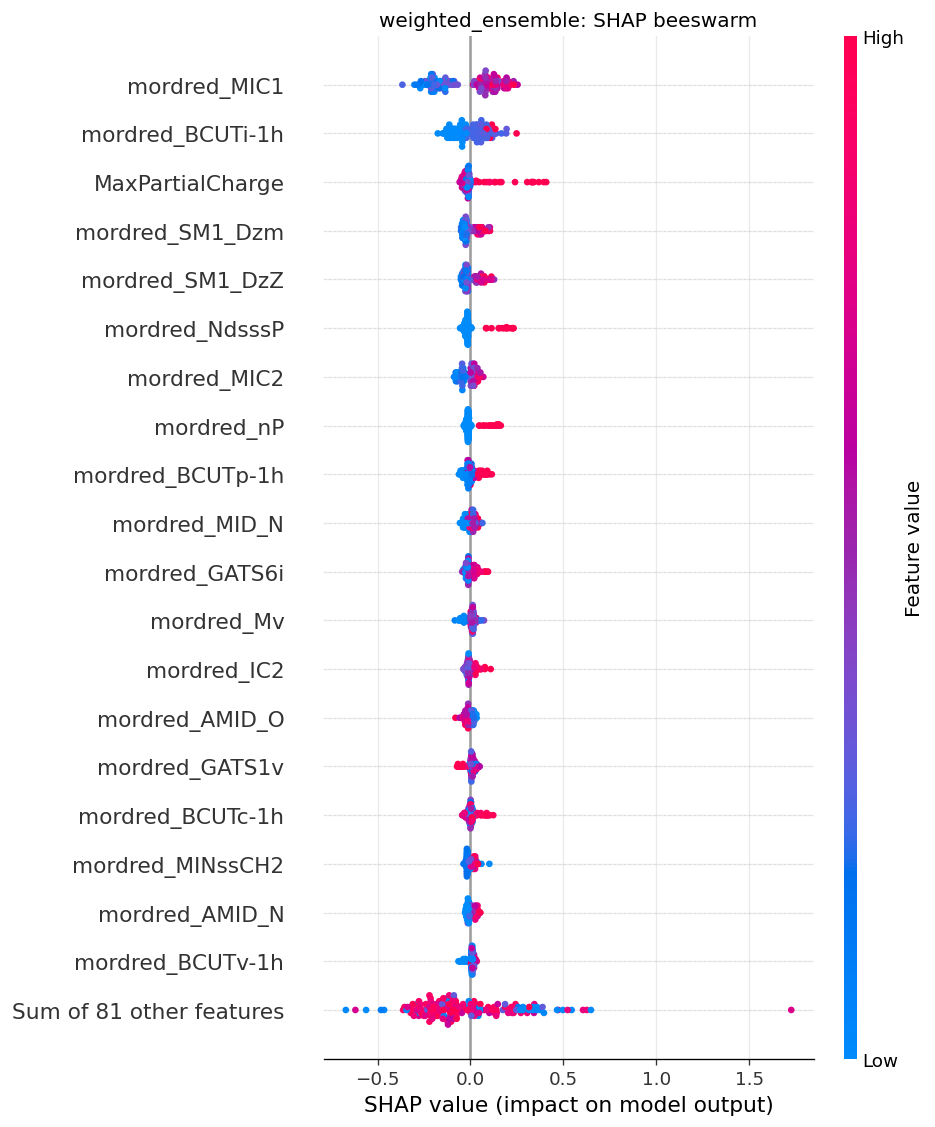

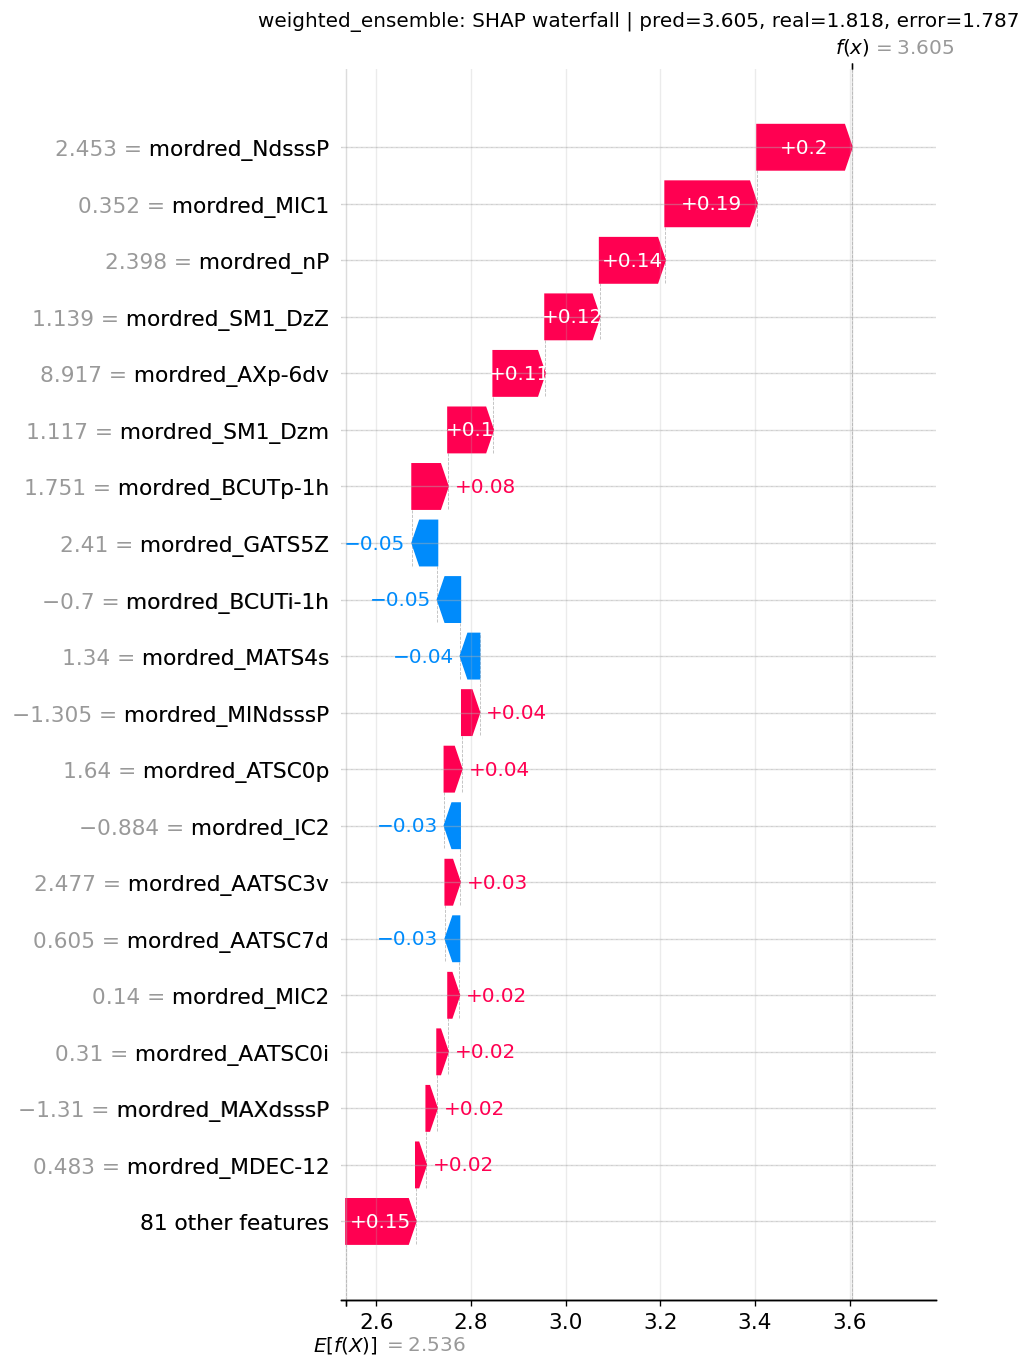

Max weighted-ensemble SHAP additivity error: 0.000005


,component,weight,explainer,component_mean_abs_shap
2,xgboost,0.866493,xgboost_pred_contribs,0.013060
0,random_forest,0.078535,TreeExplainer,0.009866
1,hist_gradient_boosting,0.054972,TreeExplainer,0.016004


In [11]:
def explain_weighted_ensemble(bundle):
    explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 5)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    pred_explain = predictions['weighted_ensemble'][explain_idx]

    ensemble_values = np.zeros((X_explain_df.shape[0], X_explain_df.shape[1]), dtype=float)
    ensemble_base_values = np.zeros(X_explain_df.shape[0], dtype=float)
    component_rows = []

    for component_name, weight in bundle['weights'].items():
        weight = float(weight)
        if abs(weight) <= 1e-8:
            continue
        component_model = bundle['models'][component_name]
        if hasattr(component_model, 'get_booster'):
            component_explanation = xgboost_contrib_explanation(component_model, X_explain_df)
            values = np.asarray(component_explanation.values, dtype=float)
            base_values = np.asarray(component_explanation.base_values, dtype=float)
            explainer_name = 'xgboost_pred_contribs'
        else:
            try:
                explainer = shap.TreeExplainer(component_model, feature_names=list(clean_feature_names))
                values = np.asarray(explainer.shap_values(X_explain_df), dtype=float)
                if values.ndim == 3:
                    values = values[:, :, 0]
                expected = explainer.expected_value
                explainer_name = type(explainer).__name__
            except Exception as exc:
                warnings.warn(f'Falling back to permutation SHAP for {component_name}: {exc}')
                background = pd.DataFrame(X_train[:BACKGROUND_SIZE], columns=clean_feature_names)
                explainer = shap.Explainer(
                    component_model.predict,
                    shap.maskers.Independent(background),
                    algorithm='permutation',
                    feature_names=list(clean_feature_names),
                )
                component_explanation = explainer(X_explain_df, max_evals=2 * X_explain_df.shape[1] + 1, silent=True)
                values = np.asarray(component_explanation.values, dtype=float)
                expected = component_explanation.base_values
                explainer_name = type(explainer).__name__

            if np.ndim(expected) == 0:
                base_values = np.full(X_explain_df.shape[0], float(expected))
            else:
                expected_arr = np.asarray(expected, dtype=float).reshape(-1)
                base_values = np.full(X_explain_df.shape[0], float(expected_arr[0])) if expected_arr.size == 1 else expected_arr

        ensemble_values += weight * values
        ensemble_base_values += weight * base_values
        component_rows.append({
            'component': component_name,
            'weight': weight,
            'explainer': explainer_name,
            'component_mean_abs_shap': float(np.abs(values).mean()),
        })

    component_table = pd.DataFrame(component_rows).sort_values('weight', ascending=False)
    component_table.to_csv(TABLES_DIR / 'weighted_ensemble_components.csv', index=False)

    explanation = shap.Explanation(
        values=ensemble_values,
        base_values=ensemble_base_values,
        data=X_explain_df.to_numpy(),
        feature_names=list(clean_feature_names),
    )
    summary = save_shap_outputs('weighted_ensemble', explanation, X_explain_df, y_test[explain_idx], pred_explain)
    additivity_error = np.max(np.abs(ensemble_base_values + ensemble_values.sum(axis=1) - pred_explain))
    print(f'Max weighted-ensemble SHAP additivity error: {additivity_error:.6f}')
    return summary, component_table

weighted_ensemble_summary, weighted_ensemble_components = explain_weighted_ensemble(weighted_ensemble)
weighted_ensemble_components


### **Global Perspective: SHAP Beeswarm**
The beeswarm plot reveals a highly refined feature hierarchy where the ensemble captures the consensus importance across different algorithmic families.

*   **mordred_MIC1 (Information Content)**: Consistent with the individual models, this remains the most critical feature. Lower feature values (blue) lead to significantly lower SHAP values (not zero), indicating a strong and consistent contribution to higher predicted toxicity (lower $LD_{50}$).
*   **mordred_BCUTi-1h (Ionization Potential)**: Lower values of this descriptor are associated with lower SHAP values, confirming that ionization potential is a key global indicator of toxicity in the combined model logic.
*   **MaxPartialCharge**: This feature shows a non-linear but highly meaningful pattern. While most lower point values cluster around zero (neutral impact), higher values are extremely meaningful. They can pull the prediction in both directions, but their impact is particularly pronounced at higher feature values, where they drive substantial shifts in the SHAP value.
*   **mordred_NdsssP**: This descriptor (related to nitrogen atom types) shows that higher values consistently push the prediction toward higher $LD_{50}$ (safety), appearing as a strong, distinct cluster in the pink region.

### **Local Perspective: SHAP Waterfall**
The waterfall plot provides a granular breakdown for a specific prediction ($f(x) = 3.605$), illustrating the cumulative "push" from the ensemble's perspective.

*   **Positive Drivers (Pushing Up)**: In this specific molecule, a significant group of features works together to increase the safety prediction. High values for **mordred_NdsssP** (+0.20), **mordred_MIC1** (+0.19), **mordred_nP** (+0.14), and **mordred_SM1_DzZ** (+0.12) are the primary contributors to the final safety score.
*   **Aggregate Impact**: Beyond the top-tier descriptors, the "Sum of others" also contributes a collective **+0.15**, suggesting that for this instance, the ensemble found many small structural cues that point toward a lower toxicity profile.

### **Conclusion on SHAP Validity**
> The Weighted Ensemble provides the most "smoothed" and reliable chemical interpretation. By inheriting the sensitivity to **basicity** from the SVM and **structural complexity** from the tree-based models, it successfully identifies **mordred_MIC1** and **MaxPartialCharge** as universal pillars of toxicity prediction while using autocorrelation and path descriptors to fine-tune local chemical environments.

## Cross-Model Comparison

Features that repeatedly appear in the top SHAP ranks are more stable interpretability signals than single-model artifacts.


In [12]:
summary_frames = []
for path in sorted(TABLES_DIR.glob('*_shap_summary.csv')):
    if path.name == 'all_models_top_shap_features.csv':
        continue
    summary_frames.append(pd.read_csv(path))

all_summaries = pd.concat(summary_frames, ignore_index=True)
all_summaries['rank_within_model'] = all_summaries.groupby('model')['mean_abs_shap'].rank(method='first', ascending=False)
top_features = all_summaries[all_summaries['rank_within_model'] <= MAX_DISPLAY].copy()
top_features.to_csv(TABLES_DIR / 'all_models_top_shap_features.csv', index=False)

overlap = (
    top_features.groupby('feature')
    .agg(
        n_models=('model', 'nunique'),
        models=('model', lambda values: ', '.join(sorted(set(values)))),
        mean_abs_shap_avg=('mean_abs_shap', 'mean'),
    )
    .sort_values(['n_models', 'mean_abs_shap_avg'], ascending=[False, False])
    .reset_index()
)
overlap.to_csv(TABLES_DIR / 'cross_model_feature_overlap.csv', index=False)
overlap.head(30)


,feature,n_models,models,mean_abs_shap_avg
0,mordred_MIC1,5,"random_forest, ridge, svm, weighted_ensemble, ...",0.172653
1,mordred_BCUTp-1h,4,"random_forest, ridge, weighted_ensemble, xgboost",0.092602
2,mordred_SM1_Dzm,4,"random_forest, ridge, weighted_ensemble, xgboost",0.052227
3,mordred_Mv,4,"random_forest, ridge, weighted_ensemble, xgboost",0.040046
4,mordred_IC2,4,"random_forest, ridge, weighted_ensemble, xgboost",0.039182
5,mordred_nP,4,"random_forest, svm, weighted_ensemble, xgboost",0.035532
6,mordred_MPC8,3,"random_forest, ridge, xgboost",0.107746
7,mordred_BCUTi-1h,3,"random_forest, weighted_ensemble, xgboost",0.087573
8,mordred_MIC2,3,"random_forest, ridge, weighted_ensemble",0.075426
9,mordred_BCUTv-1h,3,"ridge, weighted_ensemble, xgboost",0.063235


## Artifact Index


In [13]:
artifact_index = pd.DataFrame(
    [{'type': 'figure', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(FIGURES_DIR.glob('*.png'))]
    + [{'type': 'table', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(TABLES_DIR.glob('*.csv'))]
    + [{'type': 'model', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(INTERP_MODEL_DIR.glob('*.pkl'))]
)
artifact_index.to_csv(OUTCOME_DIR / 'artifact_index.csv', index=False)
artifact_index


,type,path
0,figure,outcome/figures/random_forest_shap_beeswarm.png
1,figure,outcome/figures/random_forest_shap_waterfall.png
2,figure,outcome/figures/ridge_shap_beeswarm.png
3,figure,outcome/figures/ridge_shap_waterfall.png
4,figure,outcome/figures/svm_shap_beeswarm.png
5,figure,outcome/figures/svm_shap_waterfall.png
6,figure,outcome/figures/weighted_ensemble_shap_beeswar...
7,figure,outcome/figures/weighted_ensemble_shap_waterfa...
8,figure,outcome/figures/xgboost_shap_beeswarm.png
9,figure,outcome/figures/xgboost_shap_waterfall.png
